# MOFA+ Baseline — Multi-Omics Factor Analysis

MOFA+ is the standard classical method for multi-omics integration.
We compare it against our foundation model approach.


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install -q mofapy2 anndata numpy pandas scikit-learn xgboost umap-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

INPUT_ROOT = Path("/content/drive/MyDrive/multiomics-project")
OUTPUT_ROOT = Path("/content/drive/MyDrive/multiomics-project")

RAW_DIR = INPUT_ROOT / "data/raw"
METH_H5AD = INPUT_ROOT / "data/processed/tcga_methylation.h5ad"
RNA_H5AD = INPUT_ROOT / "data/processed/tcga_rna_seq.h5ad"
PROBE_LIST = INPUT_ROOT / "data/processed/probe_ids_type3.csv"

MANIFEST_CANDIDATES = [
    INPUT_ROOT / "manifests/matched_samples.csv",
    INPUT_ROOT / "data/manifests/matched_samples.csv",
    INPUT_ROOT / "data/processed/matched_samples.csv",
    OUTPUT_ROOT / "manifests/matched_samples.csv",
    OUTPUT_ROOT / "data/manifests/matched_samples.csv",
]

MANIFEST = None
for p in MANIFEST_CANDIDATES:
    if p.exists():
        MANIFEST = p
        break

if MANIFEST is None:
    for root in [INPUT_ROOT, OUTPUT_ROOT]:
        matches = list(root.rglob("matched_samples.csv"))
        if matches:
            MANIFEST = matches[0]
            break

if MANIFEST is None:
    raise FileNotFoundError(
        "matched_samples.csv was not found. Run: "
        '!find "/content/drive/MyDrive" -name "matched_samples.csv" 2>/dev/null'
    )

OUTPUT_DIR = OUTPUT_ROOT / "results/mofa"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_FACTORS = 30
N_HVG = 2000
N_HVM = 5000
N_SPLITS = 5
RANDOM_STATE = 42

print("Methylation h5ad:", METH_H5AD.exists(), METH_H5AD)
print("RNA h5ad        :", RNA_H5AD.exists(), RNA_H5AD)
print("Raw data dir    :", RAW_DIR.exists(), RAW_DIR)
print("Probe list      :", PROBE_LIST.exists(), PROBE_LIST)
print("Manifest        :", MANIFEST.exists(), MANIFEST)
print("Output dir      :", OUTPUT_DIR.exists(), OUTPUT_DIR)


Methylation h5ad: True /content/drive/MyDrive/multiomics-project/data/processed/tcga_methylation.h5ad
RNA h5ad        : True /content/drive/MyDrive/multiomics-project/data/processed/tcga_rna_seq.h5ad
Raw data dir    : True /content/drive/MyDrive/multiomics-project/data/raw
Probe list      : True /content/drive/MyDrive/multiomics-project/data/processed/probe_ids_type3.csv
Manifest        : True /content/drive/MyDrive/multiomics-project/data/manifests/matched_samples.csv
Output dir      : True /content/drive/MyDrive/multiomics-project/results/mofa


In [ ]:
import numpy as np
import pandas as pd
import anndata as ad

from sklearn.preprocessing import LabelEncoder, StandardScaler


def to_dense(matrix):
    return matrix if isinstance(matrix, np.ndarray) else matrix.toarray()


def infer_label_column(manifest):
    for col in ["cancer_type", "Cancer type", "project_id", "project", "disease", "label"]:
        if col in manifest.columns:
            return col
    print("Manifest columns:", manifest.columns.tolist())
    raise ValueError("Could not find label column in manifest.")


def recover_probe_ids(adata_meth):
    probe_ids = adata_meth.var.index.astype(str).tolist()
    if probe_ids and (probe_ids[0].startswith("cg") or probe_ids[0].startswith("ch.")):
        return probe_ids

    probe_table = pd.read_csv(PROBE_LIST)
    probe_cols = [
        col for col in probe_table.columns
        if probe_table[col].astype(str).str.match(r"^(cg\d+|ch\.)").mean() > 0.5
    ]
    if not probe_cols:
        raise ValueError(f"Could not find CpG probe column in {PROBE_LIST}. Columns: {list(probe_table.columns)}")

    probe_lookup = probe_table[probe_cols[0]].astype(str).str.strip().tolist()
    numeric_positions = pd.to_numeric(pd.Index(probe_ids), errors="coerce")
    if numeric_positions.isna().any() or int(numeric_positions.max()) >= len(probe_lookup):
        raise ValueError("Methylation h5ad feature IDs cannot be mapped back to probe_ids_type3.csv")

    recovered = [probe_lookup[int(i)] for i in numeric_positions]
    print(f"Recovered methylation probe IDs from {PROBE_LIST.name} using column: {probe_cols[0]}")
    return recovered


def rebuild_methylation_from_raw(manifest, probe_ids):
    print("Rebuilding methylation matrix in memory from raw files. This does not save or modify preprocessing outputs.")
    data_list = []
    label_list = []

    for _, row in manifest.iterrows():
        file_path = RAW_DIR / row["project"] / "methylation" / row["meth_file_name"]
        if not file_path.exists():
            print(f"Missing raw methylation file: {file_path}")
            continue

        sample_df = pd.read_csv(file_path, sep="\t", header=None, names=["probe", "beta"])
        sample_df["probe"] = sample_df["probe"].astype(str).str.strip()
        sample_df["beta"] = pd.to_numeric(sample_df["beta"], errors="coerce")
        sample_df = sample_df.drop_duplicates("probe", keep="first").set_index("probe")

        data_list.append(sample_df.reindex(probe_ids)["beta"].to_numpy(dtype=np.float32))
        label_list.append(row["project"])

        if len(data_list) % 50 == 0:
            print(f"Loaded {len(data_list)} raw methylation files...")

    if not data_list:
        raise ValueError("No raw methylation files were loaded. Check RAW_DIR and MANIFEST paths.")

    X = np.nan_to_num(np.stack(data_list), nan=0.0)
    labels = np.array(label_list)
    return X, labels


def top_variable_indices(X, n_features, view_name):
    variances = np.nanvar(X, axis=0)
    valid = np.where(np.isfinite(variances) & (variances > 0))[0]
    if len(valid) == 0:
        raise ValueError(f"{view_name} has no variable features.")

    n_take = min(n_features, len(valid))
    selected = valid[np.argsort(variances[valid])[-n_take:]]
    print(f"{view_name}: selected {len(selected)} variable features from {X.shape[1]}")
    return selected


print("Loading data...")
adata_meth = ad.read_h5ad(METH_H5AD)
adata_rna = ad.read_h5ad(RNA_H5AD)
manifest = pd.read_csv(MANIFEST)

print("Methylation:", adata_meth.shape)
print("RNA-seq    :", adata_rna.shape)

X_meth = to_dense(adata_meth.X)
X_rna = to_dense(adata_rna.X)
probe_ids = recover_probe_ids(adata_meth)

label_col = infer_label_column(manifest)
labels = manifest[label_col].astype(str).values
print("Using label column:", label_col)
print("Cancer types:", dict(pd.Series(labels).value_counts()))

if X_meth.shape[0] != X_rna.shape[0] or X_rna.shape[0] != len(labels):
    raise ValueError(f"Sample mismatch: methylation={X_meth.shape[0]}, RNA={X_rna.shape[0]}, labels={len(labels)}")

meth_variable = int((np.nanvar(X_meth, axis=0) > 0).sum())
meth_nonzero = float(np.mean(X_meth != 0))
print(f"Variable methylation probes in h5ad: {meth_variable}/{X_meth.shape[1]}")
print(f"Non-zero methylation fraction in h5ad: {meth_nonzero:.6f}")

methylation_source = "h5ad"
if meth_variable == 0:
    X_meth, labels = rebuild_methylation_from_raw(manifest, probe_ids)
    methylation_source = "raw_files_in_memory"
    meth_variable = int((np.nanvar(X_meth, axis=0) > 0).sum())
    meth_nonzero = float(np.mean(X_meth != 0))
    print(f"Variable methylation probes after rebuild: {meth_variable}/{X_meth.shape[1]}")
    print(f"Non-zero methylation fraction after rebuild: {meth_nonzero:.6f}")

if meth_variable == 0:
    raise ValueError("Methylation is still constant after attempted rebuild; baseline would not be credible.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
class_names = [str(c) for c in label_encoder.classes_]

print("Classes:", class_names)


Loading data...
Methylation: (800, 49156)
RNA-seq    : (800, 60616)
Recovered methylation probe IDs from probe_ids_type3.csv using column: illumina_probe_id
Using label column: project
Cancer types: {'TCGA-BRCA': np.int64(134), 'TCGA-LUAD': np.int64(134), 'TCGA-COAD': np.int64(133), 'TCGA-KIRC': np.int64(133), 'TCGA-LIHC': np.int64(133), 'TCGA-THCA': np.int64(133)}
Variable methylation probes in h5ad: 0/49156
Non-zero methylation fraction in h5ad: 0.000000
Rebuilding methylation matrix in memory from raw files. This does not save or modify preprocessing outputs.
Loaded 50 raw methylation files...
Loaded 100 raw methylation files...
Loaded 150 raw methylation files...
Loaded 200 raw methylation files...
Loaded 250 raw methylation files...
Loaded 300 raw methylation files...
Loaded 350 raw methylation files...
Loaded 400 raw methylation files...
Loaded 450 raw methylation files...
Loaded 500 raw methylation files...
Loaded 550 raw methylation files...
Loaded 600 raw methylation files...


In [ ]:
from pathlib import Path
from mofapy2.run.entry_point import entry_point


def fit_mofa_on_training_fold(X_rna_train, X_meth_train, seed):
    ent = entry_point()

    ent.set_data_options(
        scale_groups=False,
        scale_views=True,
    )

    ent.set_data_matrix(
        [[X_rna_train], [X_meth_train]],
        likelihoods=["gaussian", "gaussian"],
        views_names=["RNA", "Methylation"],
        groups_names=["TCGA"],
    )

    ent.set_model_options(
        factors=N_FACTORS,
        spikeslab_weights=True,
        ard_factors=True,
        ard_weights=True,
    )

    ent.set_train_options(
        iter=1000,
        convergence_mode="fast",
        seed=seed,
        verbose=False,
    )

    ent.build()
    ent.run()

    z_train = np.asarray(ent.model.nodes["Z"].getExpectation())
    if z_train.ndim == 3:
        z_train = z_train[0]
    if z_train.shape[0] == N_FACTORS and z_train.shape[1] == X_rna_train.shape[0]:
        z_train = z_train.T
    if z_train.shape[0] != X_rna_train.shape[0]:
        raise ValueError(f"Unexpected train-fold MOFA factor shape: {z_train.shape}")

    return z_train


def project_test_samples_from_train_factors(X_train_concat, z_train, X_test_concat, ridge=1e-3):
    gram = X_train_concat @ X_train_concat.T
    gram.flat[:: gram.shape[0] + 1] += ridge
    alpha = np.linalg.solve(gram, z_train)
    return X_test_concat @ X_train_concat.T @ alpha


def prepare_fold_views(train_idx, test_idx):
    top_meth = top_variable_indices(X_meth[train_idx], N_HVM, "Methylation train fold")
    top_rna = top_variable_indices(X_rna[train_idx], N_HVG, "RNA train fold")

    meth_scaler = StandardScaler()
    rna_scaler = StandardScaler()

    X_meth_train = meth_scaler.fit_transform(X_meth[train_idx][:, top_meth])
    X_meth_test = meth_scaler.transform(X_meth[test_idx][:, top_meth])
    X_rna_train = rna_scaler.fit_transform(X_rna[train_idx][:, top_rna])
    X_rna_test = rna_scaler.transform(X_rna[test_idx][:, top_rna])

    X_meth_train = np.nan_to_num(X_meth_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_meth_test = np.nan_to_num(X_meth_test, nan=0.0, posinf=0.0, neginf=0.0)
    X_rna_train = np.nan_to_num(X_rna_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_rna_test = np.nan_to_num(X_rna_test, nan=0.0, posinf=0.0, neginf=0.0)

    X_train_concat = np.hstack([X_rna_train, X_meth_train])
    X_test_concat = np.hstack([X_rna_test, X_meth_test])

    fold_info = {
        "n_methylation_features": int(X_meth_train.shape[1]),
        "n_rna_features": int(X_rna_train.shape[1]),
    }
    return X_rna_train, X_meth_train, X_train_concat, X_test_concat, fold_info


def fit_project_fold(train_idx, test_idx, fold):
    X_rna_train, X_meth_train, X_train_concat, X_test_concat, fold_info = prepare_fold_views(train_idx, test_idx)
    print(f"Fold {fold}: fitting MOFA on {len(train_idx)} training samples only...")
    z_train = fit_mofa_on_training_fold(X_rna_train, X_meth_train, RANDOM_STATE + fold)
    z_test = project_test_samples_from_train_factors(X_train_concat, z_train, X_test_concat)

    fold_info.update({
        "fold": int(fold),
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "n_factors": int(z_train.shape[1]),
    })
    return z_train, z_test, fold_info

print("Defined strict out-of-fold MOFA helpers.")
print("Each fold will fit MOFA on training samples only; held-out samples are projected from training-fold factors.")


Defined strict out-of-fold MOFA helpers.
Each fold will fit MOFA on training samples only; held-out samples are projected from training-fold factors.


In [6]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from xgboost import XGBClassifier

print("Evaluating strict MOFA+ baseline with train-fold-only MOFA and XGBoost...")


def make_xgboost(seed):
    return XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=seed,
        n_jobs=-1,
    )


def compute_fold_metrics(labels_true, pred, proba):
    try:
        auc_macro = roc_auc_score(labels_true, proba, multi_class="ovr", average="macro")
    except ValueError:
        auc_macro = np.nan

    return {
        "accuracy": accuracy_score(labels_true, pred),
        "f1_macro": f1_score(labels_true, pred, average="macro"),
        "f1_weighted": f1_score(labels_true, pred, average="weighted"),
        "precision_macro": precision_score(labels_true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(labels_true, pred, average="macro", zero_division=0),
        "auc_ovr_macro": auc_macro,
    }


def make_cv_splits():
    if "case_id" in manifest.columns and manifest["case_id"].nunique() < len(manifest):
        groups = manifest["case_id"].astype(str).values
        splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        return list(splitter.split(X_rna, y_encoded, groups)), "StratifiedGroupKFold(case_id)"

    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    return list(splitter.split(X_rna, y_encoded)), "StratifiedKFold"


def evaluate_raw_control(view_name, X_left, X_right=None):
    rows = []
    for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
        if X_right is None:
            top_left = top_variable_indices(X_left[train_idx], N_HVG if view_name == "RNA_only" else N_HVM, f"{view_name} train fold")
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_left[train_idx][:, top_left])
            X_test = scaler.transform(X_left[test_idx][:, top_left])
        else:
            top_left = top_variable_indices(X_left[train_idx], N_HVG, "RNA raw-control train fold")
            top_right = top_variable_indices(X_right[train_idx], N_HVM, "Methylation raw-control train fold")
            left_scaler = StandardScaler()
            right_scaler = StandardScaler()
            X_train = np.hstack([
                left_scaler.fit_transform(X_left[train_idx][:, top_left]),
                right_scaler.fit_transform(X_right[train_idx][:, top_right]),
            ])
            X_test = np.hstack([
                left_scaler.transform(X_left[test_idx][:, top_left]),
                right_scaler.transform(X_right[test_idx][:, top_right]),
            ])

        X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
        X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
        clf = make_xgboost(RANDOM_STATE + 500 + fold)
        clf.fit(X_train, y_encoded[train_idx])
        pred = clf.predict(X_test).astype(int)
        proba = clf.predict_proba(X_test)

        row = {
            "baseline": view_name,
            "classifier": "XGBoost",
            "evaluation": f"raw-omics task difficulty control, {cv_strategy}",
            "fold": fold,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
        }
        row.update(compute_fold_metrics(y_encoded[test_idx], pred, proba))
        rows.append(row)
    return pd.DataFrame(rows)


cv_splits, cv_strategy = make_cv_splits()
print("CV strategy:", cv_strategy)
fold_rows = []
control_rows = []
fold_info_rows = []
oof_pred = np.full(len(y_encoded), fill_value=-1, dtype=int)
oof_proba = np.zeros((len(y_encoded), len(class_names)), dtype=float)
mofa_oof_embedding = None

rng = np.random.default_rng(RANDOM_STATE)
shuffled_labels = rng.permutation(y_encoded)

for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    z_train, z_test, fold_info = fit_project_fold(train_idx, test_idx, fold)
    fold_info_rows.append(fold_info)

    if mofa_oof_embedding is None:
        mofa_oof_embedding = np.full((len(y_encoded), z_test.shape[1]), np.nan, dtype=float)
    mofa_oof_embedding[test_idx] = z_test

    clf = make_xgboost(RANDOM_STATE + fold)
    clf.fit(z_train, y_encoded[train_idx])
    pred = clf.predict(z_test).astype(int)
    proba = clf.predict_proba(z_test)

    oof_pred[test_idx] = pred
    oof_proba[test_idx] = proba

    row = {
        "baseline": "MOFA+",
        "classifier": "XGBoost",
        "evaluation": "strict train-fold MOFA + held-out projection",
        "fold": fold,
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
    }
    row.update(compute_fold_metrics(y_encoded[test_idx], pred, proba))
    fold_rows.append(row)

    control_clf = make_xgboost(RANDOM_STATE + 100 + fold)
    control_clf.fit(z_train, shuffled_labels[train_idx])
    control_pred = control_clf.predict(z_test).astype(int)
    control_proba = control_clf.predict_proba(z_test)

    control_row = {
        "baseline": "MOFA+",
        "classifier": "XGBoost_shuffled_labels_control",
        "evaluation": "strict train-fold MOFA + held-out projection",
        "fold": fold,
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
    }
    control_row.update(compute_fold_metrics(shuffled_labels[test_idx], control_pred, control_proba))
    control_rows.append(control_row)

fold_metrics = pd.DataFrame(fold_rows)
shuffled_fold_metrics = pd.DataFrame(control_rows)
fold_info = pd.DataFrame(fold_info_rows)

print("Running raw-omics task difficulty controls...")
raw_control_metrics = pd.concat([
    evaluate_raw_control("RNA_only", X_rna),
    evaluate_raw_control("Methylation_only", X_meth),
    evaluate_raw_control("RNA_plus_methylation", X_rna, X_meth),
], ignore_index=True)

fold_metrics_path = OUTPUT_DIR / "baseline_fold_metrics.csv"
control_path = OUTPUT_DIR / "shuffled_label_control_fold_metrics.csv"
raw_control_path = OUTPUT_DIR / "raw_omics_task_difficulty_controls.csv"
fold_info_path = OUTPUT_DIR / "mofa_fold_metadata.csv"
fold_metrics.to_csv(fold_metrics_path, index=False)
shuffled_fold_metrics.to_csv(control_path, index=False)
raw_control_metrics.to_csv(raw_control_path, index=False)
fold_info.to_csv(fold_info_path, index=False)

mofa_embedding = mofa_oof_embedding
np.save(OUTPUT_DIR / "mofa_oof_embedding.npy", mofa_embedding)

summary = {
    "baseline": "MOFA+",
    "classifier": "XGBoost",
    "evaluation": "strict train-fold MOFA + held-out projection",
    "representation_fit": "MOFA fit separately inside each CV training fold; held-out samples not used for MOFA fitting, feature selection, or scaling",
    "cv_strategy": cv_strategy,
    "n_samples": int(len(y_encoded)),
    "n_classes": int(len(class_names)),
    "n_factors": int(mofa_embedding.shape[1]),
    "n_methylation_features_mean": float(fold_info["n_methylation_features"].mean()),
    "n_rna_features_mean": float(fold_info["n_rna_features"].mean()),
    "methylation_source": methylation_source,
    "random_state": int(RANDOM_STATE),
}
for metric in ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro", "auc_ovr_macro"]:
    summary[f"{metric}_mean"] = float(fold_metrics[metric].mean())
    summary[f"{metric}_std"] = float(fold_metrics[metric].std(ddof=0))
    summary[f"shuffled_{metric}_mean"] = float(shuffled_fold_metrics[metric].mean())
    for control_name, control_df in raw_control_metrics.groupby("baseline"):
        summary[f"{control_name}_{metric}_mean"] = float(control_df[metric].mean())

baseline_metrics = pd.DataFrame([summary])
baseline_metrics_path = OUTPUT_DIR / "baseline_metrics.csv"
baseline_metrics.to_csv(baseline_metrics_path, index=False)

report_df = pd.DataFrame(
    classification_report(
        y_encoded,
        oof_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )
).T
report_path = OUTPUT_DIR / "baseline_classification_report.csv"
report_df.to_csv(report_path)

confusion_df = pd.DataFrame(
    confusion_matrix(y_encoded, oof_pred),
    index=class_names,
    columns=class_names,
)
confusion_path = OUTPUT_DIR / "baseline_confusion_matrix.csv"
confusion_df.to_csv(confusion_path)

prediction_rows = pd.DataFrame({
    "sample_index": np.arange(len(y_encoded)),
    "true_label": label_encoder.inverse_transform(y_encoded),
    "predicted_label": label_encoder.inverse_transform(oof_pred),
})
for class_idx, class_name in enumerate(class_names):
    prediction_rows[f"proba_{class_name}"] = oof_proba[:, class_idx]
predictions_path = OUTPUT_DIR / "baseline_predictions.csv"
prediction_rows.to_csv(predictions_path, index=False)

print("Saved baseline metrics:", baseline_metrics_path)
print("Saved fold metrics:", fold_metrics_path)
print("Saved shuffled-label control:", control_path)
print("Saved raw-omics task difficulty controls:", raw_control_path)
print("Saved fold metadata:", fold_info_path)
print("Saved out-of-fold MOFA embedding:", OUTPUT_DIR / "mofa_oof_embedding.npy")
print("Saved classification report:", report_path)
print("Saved confusion matrix:", confusion_path)
print("Saved predictions:", predictions_path)
display(baseline_metrics)
display(fold_metrics)
display(shuffled_fold_metrics)
display(raw_control_metrics)


Evaluating strict MOFA+ baseline with train-fold-only MOFA and XGBoost...
CV strategy: StratifiedKFold
Methylation train fold: selected 5000 variable features from 49156
RNA train fold: selected 2000 variable features from 60616
Fold 1: fitting MOFA on 640 training samples only...

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature

,baseline,classifier,evaluation,representation_fit,cv_strategy,n_samples,n_classes,n_factors,n_methylation_features_mean,n_rna_features_mean,...,shuffled_recall_macro_mean,Methylation_only_recall_macro_mean,RNA_only_recall_macro_mean,RNA_plus_methylation_recall_macro_mean,auc_ovr_macro_mean,auc_ovr_macro_std,shuffled_auc_ovr_macro_mean,Methylation_only_auc_ovr_macro_mean,RNA_only_auc_ovr_macro_mean,RNA_plus_methylation_auc_ovr_macro_mean
0,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,MOFA fit separately inside each CV training fo...,StratifiedKFold,800,6,30,5000.0,2000.0,...,0.180971,0.990028,0.995014,0.995014,0.999344,0.000376,0.511993,0.999934,0.999934,0.999971


,baseline,classifier,evaluation,fold,n_train,n_test,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,auc_ovr_macro
0,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,1,640,160,0.98125,0.981346,0.981235,0.982095,0.981244,0.999861
1,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,2,640,160,0.98125,0.981244,0.981250,0.981244,0.981244,0.999534
2,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,3,640,160,0.98125,0.981465,0.981233,0.982333,0.981481,0.998793
3,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,4,640,160,0.95625,0.956285,0.956342,0.957608,0.956078,0.999056
4,MOFA+,XGBoost,strict train-fold MOFA + held-out projection,5,640,160,0.98125,0.981346,0.981353,0.982333,0.981244,0.999474


,baseline,classifier,evaluation,fold,n_train,n_test,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,auc_ovr_macro
0,MOFA+,XGBoost_shuffled_labels_control,strict train-fold MOFA + held-out projection,1,640,160,0.15625,0.159697,0.167028,0.178800,0.151829,0.511316
1,MOFA+,XGBoost_shuffled_labels_control,strict train-fold MOFA + held-out projection,2,640,160,0.12500,0.123954,0.124689,0.130210,0.128745,0.498169
2,MOFA+,XGBoost_shuffled_labels_control,strict train-fold MOFA + held-out projection,3,640,160,0.20000,0.200547,0.202773,0.206955,0.201522,0.542764
3,MOFA+,XGBoost_shuffled_labels_control,strict train-fold MOFA + held-out projection,4,640,160,0.20000,0.199262,0.202024,0.207027,0.197357,0.504112
4,MOFA+,XGBoost_shuffled_labels_control,strict train-fold MOFA + held-out projection,5,640,160,0.21875,0.218228,0.216309,0.221863,0.225400,0.503604


,baseline,classifier,evaluation,fold,n_train,n_test,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,auc_ovr_macro
0,RNA_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",1,640,160,0.99375,0.993825,0.993748,0.994048,0.993827,1.000000
1,RNA_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",2,640,160,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
2,RNA_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",3,640,160,0.98750,0.987654,0.987500,0.987654,0.987654,0.999861
3,RNA_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",4,640,160,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
4,RNA_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",5,640,160,0.99375,0.993702,0.993746,0.994048,0.993590,0.999809
5,Methylation_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",1,640,160,0.98750,0.987536,0.987498,0.987875,0.987654,0.999907
6,Methylation_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",2,640,160,0.99375,0.993825,0.993748,0.994048,0.993827,1.000000
7,Methylation_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",3,640,160,0.98750,0.987758,0.987605,0.988506,0.987654,0.999907
8,Methylation_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",4,640,160,0.99375,0.993702,0.993746,0.994048,0.993590,0.999856
9,Methylation_only,XGBoost,"raw-omics task difficulty control, StratifiedK...",5,640,160,0.98750,0.987412,0.987496,0.987875,0.987417,1.000000


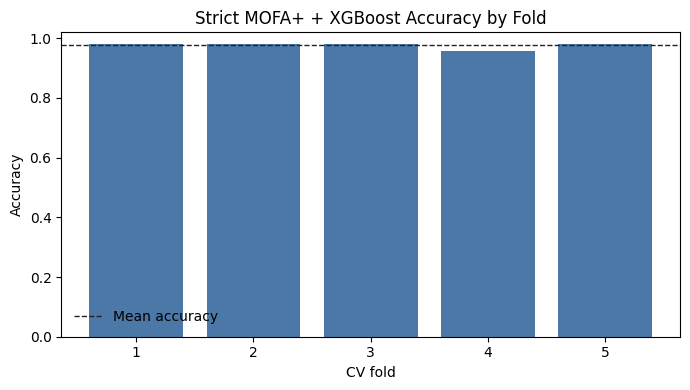

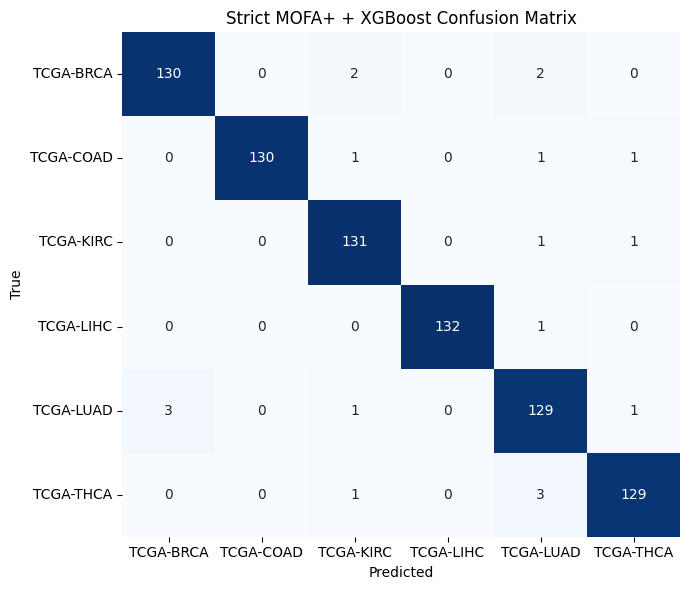

Saved plots:
  /content/drive/MyDrive/multiomics-project/results/mofa/baseline_fold_accuracy.png
  /content/drive/MyDrive/multiomics-project/results/mofa/baseline_confusion_matrix.png


In [7]:
# Visual QC for the strict baseline metrics
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = fold_metrics.copy()
ax.bar(plot_df["fold"].astype(str), plot_df["accuracy"], color="#4C78A8")
ax.axhline(plot_df["accuracy"].mean(), color="#222222", linestyle="--", linewidth=1, label="Mean accuracy")
ax.set_ylim(0, 1.02)
ax.set_xlabel("CV fold")
ax.set_ylabel("Accuracy")
ax.set_title("Strict MOFA+ + XGBoost Accuracy by Fold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_fold_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Strict MOFA+ + XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(" ", OUTPUT_DIR / "baseline_fold_accuracy.png")
print(" ", OUTPUT_DIR / "baseline_confusion_matrix.png")
